# Deep CNN Image Classification

This notebook implements and trains the Deep Convolutional Neural Network (Deep CNN)
for six-class natural scene image classification using the Intel Image Classification Dataset.

## Model Configuration

- Input Size: 224 × 224 × 3
- Number of Classes: 6
- Activation Function: ReLU
- Output Activation: Softmax
- Loss Function: Sparse Categorical Crossentropy
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Maximum Epochs: 30
- Dropout Rate: 0.5

In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Imports and Setup

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models

## 2. Dataset Loading

In [7]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_path = "../dataset/Dataset/train"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Classes:", train_ds.class_names)

Found 12632 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [8]:
import os

print(os.getcwd())

d:\4th Year\Modules\SE4050 - DL\DL Assignment\deep-learning-image-classification\notebooks


In [9]:
val_path = "../dataset/Dataset/val"

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Validation classes:", val_ds.class_names)

Found 1402 files belonging to 6 classes.
Validation classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [12]:
test_path = "../dataset/Dataset/test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test classes:", test_ds.class_names)

Found 3000 files belonging to 6 classes.
Test classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 3. Preprocessing and Normalization

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

val_ds = val_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_ds = test_ds.map(
    lambda images, labels: (normalization_layer(images), labels)
)

## 4. Data Augmentation

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])

## 5. Deep CNN Architecture

In [16]:
def build_deep_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(6, activation="softmax")
    ])

    return model

In [17]:
model = build_deep_cnn()

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,086 (1.61 MB)

 Trainable params: 422,086 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Model Compilation

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
train_ds_augmented = train_ds.map(
    lambda images, labels: (data_augmentation(images, training=True), labels)
)

## 7. Training Configuration

In [20]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "../models/deep_cnn_best.keras",
    monitor="val_loss",
    save_best_only=True
)

In [21]:
EPOCHS = 30

print("Training configuration:")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", 0.001)

Training configuration:
Epochs: 30
Batch size: 32
Learning rate: 0.001


## 8. Model Training

In [22]:
history = model.fit(
    train_ds_augmented,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

Epoch 1/30


C:\Users\Mineth\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


395/395 ━━━━━━━━━━━━━━━━━━━━ 301s 754ms/step - accuracy: 0.4279 - loss: 1.3254 - val_accuracy: 0.5271 - val_loss: 1.1153
Epoch 2/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 277s 701ms/step - accuracy: 0.5239 - loss: 1.1447 - val_accuracy: 0.5984 - val_loss: 0.9828
Epoch 3/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 275s 695ms/step - accuracy: 0.5935 - loss: 1.0288 - val_accuracy: 0.6491 - val_loss: 0.8913
Epoch 4/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 275s 696ms/step - accuracy: 0.6453 - loss: 0.9210 - val_accuracy: 0.6940 - val_loss: 0.8075
Epoch 5/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 281s 712ms/step - accuracy: 0.6841 - loss: 0.8420 - val_accuracy: 0.7389 - val_loss: 0.7200
Epoch 6/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 290s 733ms/step - accuracy: 0.7097 - loss: 0.7867 - val_accuracy: 0.7675 - val_loss: 0.6374
Epoch 7/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 343s 866ms/step - accuracy: 0.7341 - loss: 0.7450 - val_accuracy: 0.7896 - val_loss: 0.5942
Epoch 8/30
395/395 ━━━━━━━━━━━━━━━━━━━━ 2244s 6s/step - accuracy: 0.7418 - loss: 0.7156

## 9. Test Set Evaluation

In [13]:
best_model = tf.keras.models.load_model("../models/deep_cnn_best.keras")

print("Best Deep CNN model loaded successfully.")

Best Deep CNN model loaded successfully.


In [24]:
test_loss, test_accuracy = best_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.8543 - loss: 0.4173
Test Loss: 0.41729623079299927
Test Accuracy: 0.8543333411216736


In [18]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions regenerated successfully.")
print("Number of test samples:", len(y_true))

Predictions regenerated successfully.
Number of test samples: 3000


## 10. Classification Metrics

In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.857211212637976
Recall: 0.8543333333333333
F1-Score: 0.8548438160252526


## 11. Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[394   0   1   1   2  39]
 [  5 448   0   5   1  15]
 [ 12   1 447  68  20   5]
 [ 12   1  65 414  29   4]
 [ 21   2  28  20 434   5]
 [ 67   1   0   2   5 426]]


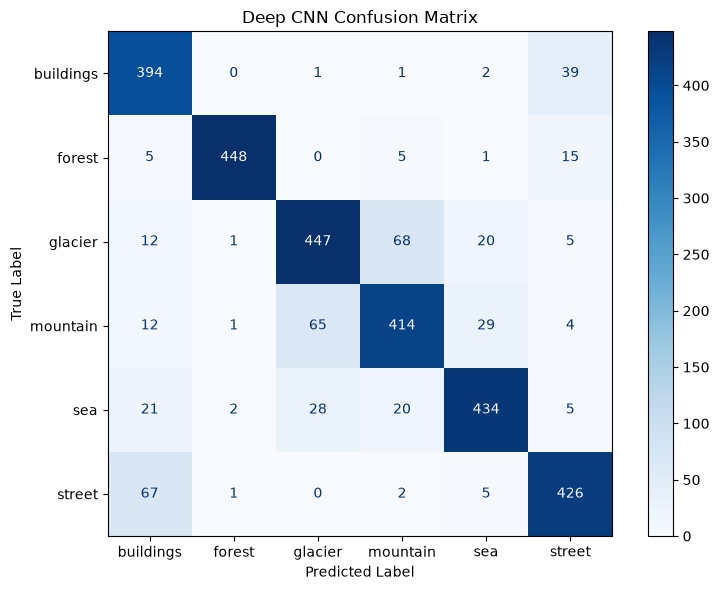

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Deep CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("../figures/deep_cnn_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

## 12. ROC-AUC Evaluation

In [26]:
y_prob = []

for images, labels in test_ds:
    probabilities = best_model.predict(images, verbose=0)
    y_prob.extend(probabilities)

y_prob = np.array(y_prob)

print("Class probabilities generated successfully.")
print("Probability shape:", y_prob.shape)

Class probabilities generated successfully.
Probability shape: (3000, 6)


In [27]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_true_one_hot = label_binarize(
    y_true,
    classes=np.arange(6)
)

roc_auc = roc_auc_score(
    y_true_one_hot,
    y_prob,
    multi_class="ovr",
    average="weighted"
)

print("Weighted ROC-AUC:", roc_auc)

Weighted ROC-AUC: 0.9807732710677904


In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Deep CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/deep_cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>

In [29]:
epochs = range(1, 31)

train_accuracy = [
    0.4279, 0.5239, 0.5935, 0.6453, 0.6841,
    0.7097, 0.7341, 0.7418, 0.7546, 0.7660,
    0.7696, 0.7811, 0.7874, 0.7899, 0.7990,
    0.8003, 0.8057, 0.8090, 0.8171, 0.8224,
    0.8168, 0.8251, 0.8230, 0.8299, 0.8341,
    0.8352, 0.8378, 0.8374, 0.8437, 0.8422
]

val_accuracy = [
    0.5271, 0.5984, 0.6491, 0.6940, 0.7389,
    0.7675, 0.7896, 0.7825, 0.7953, 0.7760,
    0.8010, 0.8046, 0.8081, 0.8124, 0.7996,
    0.8310, 0.8203, 0.8224, 0.8295, 0.8074,
    0.8367, 0.8388, 0.8388, 0.8395, 0.8431,
    0.8502, 0.8466, 0.8595, 0.8545, 0.8481
]

train_loss = [
    1.3254, 1.1447, 1.0288, 0.9210, 0.8420,
    0.7867, 0.7450, 0.7156, 0.6757, 0.6558,
    0.6443, 0.6191, 0.5992, 0.5882, 0.5672,
    0.5493, 0.5468, 0.5314, 0.5210, 0.5089,
    0.5093, 0.4943, 0.4947, 0.4778, 0.4613,
    0.4595, 0.4586, 0.4454, 0.4439, 0.4338
]

val_loss = [
    1.1153, 0.9828, 0.8913, 0.8075, 0.7200,
    0.6374, 0.5942, 0.6212, 0.5657, 0.6634,
    0.5578, 0.5728, 0.5434, 0.5485, 0.5962,
    0.5039, 0.5329, 0.5062, 0.5227, 0.5435,
    0.4742, 0.4648, 0.4585, 0.4668, 0.4352,
    0.4645, 0.4494, 0.4212, 0.4252, 0.4419
]

print("Training history recreated successfully.")
print("Number of epochs:", len(epochs))

Training history recreated successfully.
Number of epochs: 30


## 13. Training Curves

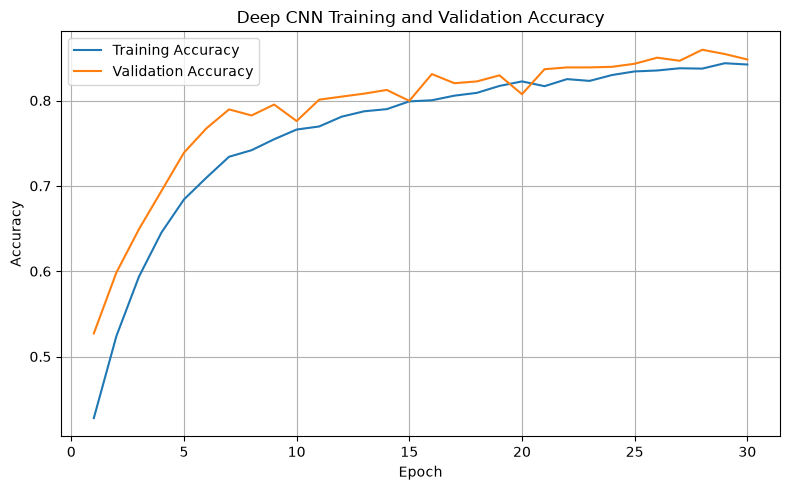

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracy, label="Training Accuracy")
plt.plot(epochs, val_accuracy, label="Validation Accuracy")

plt.title("Deep CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/deep_cnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

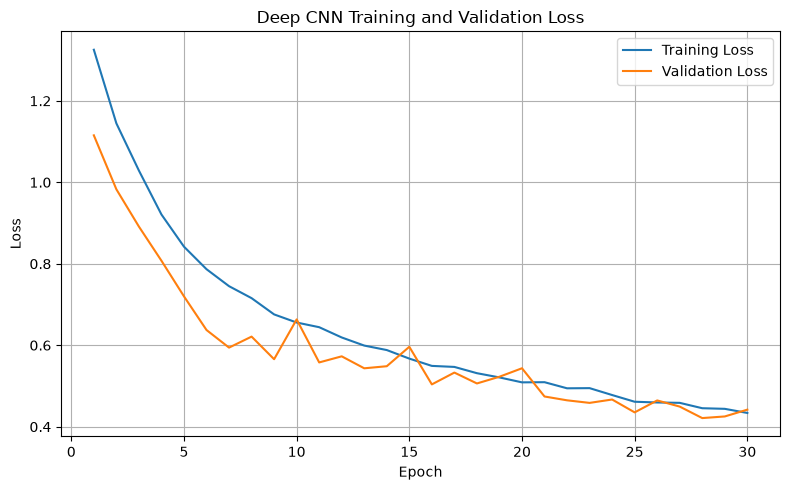

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.title("Deep CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/deep_cnn_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Results Summary

### Best Validation Performance

- Best validation accuracy: **85.95%**
- Best validation loss: **0.4212**
- Best epoch: **28**

### Test Set Performance

- Test accuracy: **85.43%**
- Precision: **85.72%**
- Recall: **85.43%**
- F1-score: **85.48%**
- Weighted ROC-AUC: **98.08%**

### Model Configuration

- Input size: **224 × 224 × 3**
- Convolutional layers: **4**
- Optimizer: **Adam**
- Learning rate: **0.001**
- Batch size: **32**
- Maximum epochs: **30**
- Dropout: **0.5**